# Introduction
Bidirectional Encoder Representations from Transformers (BERT), introduced by Google, is a state of the art natural language processing (NLP) model designed to understand the contextual relationships between words in a text.

Unlike traditional machine learning models that rely on feature engineering techniques such as TF-IDF, BERT uses deep learning and transformer model to capture bidirectional context from both left and right sides of a sentence.

In this notebook, BERT is applied to the task of sentiment analysis, where the objective is to classify text data into predefined sentiment categories (positive or negative). 

The workflow includes data preprocessing, tokenization using BERT’s tokenizer, model training, and performance evaluation using metrics such as accuracy, precision, recall, and F1-score. The use of BERT is expected to improve classification performance due to its ability to capture semantic meaning and contextual nuances in text data.

This approach provides a more robust alternative to traditional models, particularly for handling complex language patterns, making it highly suitable for real-world sentiment analysis tasks.


In [1]:
# Install Neccsesary libraries
!pip install joblib pandas scipy scikit-learn transformers datasets torch 
!pip install "accelerate>=1.1.0"

In [36]:
#Import Neccessary libraries

import pandas as pd
import torch
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

from datasets import Dataset
from transformers import BertTokenizer
from transformers import BertForSequenceClassification
from transformers import DistilBertForSequenceClassification
from transformers import TrainingArguments, Trainer

### Load the data set

In [3]:
df = pd.read_csv("amazon_reviews_processed.csv", low_memory=False)

### Load shared labels from preprocessing

These labels were already created in the shared preprocessing notebook, so we reuse them here.

In [4]:
y_train = joblib.load("shared/y_train.pkl")
y_test = joblib.load("shared/y_test.pkl")

### Load the same train/test text split
Since the labels preserve the original indices, we use them to extract the correct reviews

In [5]:
X_train_text = df.loc[y_train.index, "reviewText_processed"]
X_test_text = df.loc[y_test.index, "reviewText_processed"]

### Convert labels to numeric
BERT requires numeric labels.

In [6]:
y_train = y_train.map({"negative": 0, "positive": 1})
y_test = y_test.map({"negative": 0, "positive": 1})

### Create the training dataframe

In [7]:
train_df = pd.DataFrame({
    "text": X_train_text,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test_text,
    "label": y_test
})

### Check class imbalance

In [8]:
train_df["label"].value_counts()

label
1    568467
0     93451
Name: count, dtype: int64

If BERT is trained on this distribution, the model may learn to Predict positive most of the time.

Example:

If the model predicts positive for every review, it would already get:

86% accuracy

But it would completely fail at detecting negative reviews, which is the real challenge.

one of the strategy to consider is to balance the training data

Keep all negatives and sample equal positives.

### Balance the training data

In [9]:
negative = train_df[train_df["label"] == 0]
positive = train_df[train_df["label"] == 1]

positive_sample = positive.sample(len(negative), random_state=42)

train_balanced = pd.concat([negative, positive_sample])
train_balanced = train_balanced.sample(frac=1, random_state=42)

In [10]:
print("Negative:", len(negative))
print("Positive:", len(positive))
print("Sampled Positive:", len(positive_sample))
print("Balanced dataset:", len(train_balanced))

Negative: 93451
Positive: 568467
Sampled Positive: 93451
Balanced dataset: 186902


In [11]:
# verify the balance
train_balanced["label"].value_counts()

label
0    93451
1    93451
Name: count, dtype: int64

### Handling Class Imbalance with a Balanced Training Set

To address this issue, the training dataset was balanced through downsampling of the majority class. All negative samples were retained, and an equal number of positive samples were randomly selected to match the number of negative reviews. This resulted in a balanced training dataset containing **93,451 positive reviews** and **93,451 negative reviews**, for a total of **186,902 training samples**.

Balancing the training data helps ensure that the model learns meaningful patterns for both sentiment classes rather than relying on the dominant class distribution. However, the **test dataset was intentionally left unchanged**, preserving the original class distribution to provide a realistic evaluation of the model’s performance on real-world data.

This approach improves the model's ability to detect negative sentiment while maintaining a fair assessment of its predictive performance.

### Convert to Hugging Face dataset

In [12]:
train_dataset = Dataset.from_pandas(train_balanced)
test_dataset = Dataset.from_pandas(test_df)

### Load the tokenizer
The tokenizer converts text into tokens and numerical IDs that BERT understands.

In [13]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

### Tokenize the dataset

In [14]:
def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

### Apply the tokenization

In [15]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/186902 [00:00<?, ? examples/s]

Map:   0%|          | 0/165480 [00:00<?, ? examples/s]

### BERT training making use of PyTorch tensors

In [16]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

### Load the BERT model
Load the pretrained BERT model that has configured for binary classification


In [21]:

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training Setup

In [22]:
training_args = TrainingArguments(
    #directory where the trained model, checkpoints, and output is saved
    output_dir="./results",

    #Model evaluation after each training epoch
    eval_strategy="epoch",

    #learning rate controlling how quickly the model updates during training
    learning_rate=2e-5,

    #number of training samples processed at once on each device 
    per_device_train_batch_size=16,

    #number of evaluation samples processed at once during validation
    per_device_eval_batch_size=16,

    # number of time the model will go through the training dataset
    num_train_epochs=2,

    #technique to reduce overfitting
    weight_decay=0.01
)

### Train the model

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)
print("Starting model training...")
trainer.train()

Starting model training...


/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.265265,0.322815
2,0.219560,0.289968


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=23364, training_loss=0.2691015443702284, metrics={'train_runtime': 26556.254, 'train_samples_per_second': 14.076, 'train_steps_per_second': 0.88, 'total_flos': 1.2379210871801856e+16, 'train_loss': 0.2691015443702284, 'epoch': 2.0})

### Training Summary

The model completed training after 23,364 training steps over two epochs. The final training loss was 0.269, indicating that the model was able to learn meaningful patterns from the dataset. 

The total training time was approximately 26,556 seconds (around 7 hours), processing around 14 samples per second. Overall, the training process finished successfully and the model is ready for evaluation on the test dataset.

### Model Choice Adjustment: From BERT to DistilBERT

During initial experimentation, the project used **BERT (bert-base-uncased)** for sentiment classification. However, training the model on the full dataset resulted in very long training times (approximately **12 hours**) on the available hardware.

This limitation was partly due to the computational requirements of BERT and the hardware being used. Apple devices, in particular, may have limitations compared to systems with dedicated NVIDIA GPUs, which can significantly accelerate deep learning training.

To improve efficiency and ensure that the model could be trained within a reasonable time across different devices, the model was switched to **DistilBERT**. DistilBERT is a smaller and more efficient version of BERT that retains most of BERT’s performance while requiring fewer computational resources.

After switching to DistilBERT and optimizing the token length, the estimated training time was reduced from **approximately 12 hours to around 5 hours**. This change provides a practical balance between performance and efficiency, allowing the model to train faster while remaining accessible for users running the code on different types of hardware.

### Evaluate the model

Generate predictions and evaluate performance.

In [39]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.898791394730481
              precision    recall  f1-score   support

           0       0.60      0.90      0.72     23530
           1       0.98      0.90      0.94    141950

    accuracy                           0.90    165480
   macro avg       0.79      0.90      0.83    165480
weighted avg       0.93      0.90      0.91    165480



### Model Evaluation Results

The trained model achieved an accuracy of 0.898 on the test dataset. The results show strong overall performance, particularly for the positive class (label 1), which achieved a precision of 0.98 and an F1-score of 0.94. 

For the negative class (label 0), the model achieved a recall of 0.90, indicating that most negative reviews were correctly identified, though the precision was lower at 0.60. 

Overall, the weighted F1-score of 0.91 suggests that the model performs well on the dataset, with particularly strong performance in identifying positive sentiment.

## Confusion matrix

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.898791394730481
F1 Score: 0.9384291869476347
              precision    recall  f1-score   support

           0       0.60      0.90      0.72     23530
           1       0.98      0.90      0.94    141950

    accuracy                           0.90    165480
   macro avg       0.79      0.90      0.83    165480
weighted avg       0.93      0.90      0.91    165480



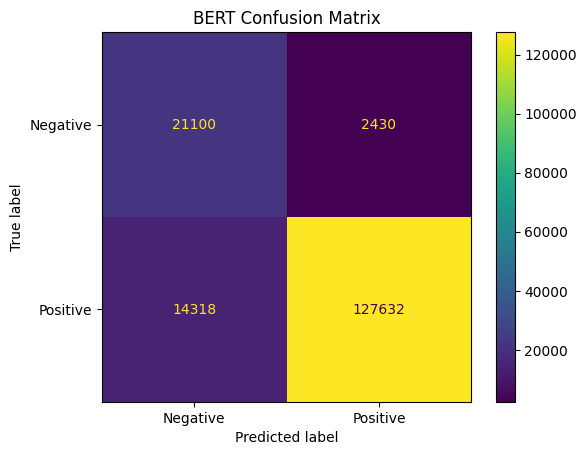

In [37]:
predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot()
plt.title("BERT Confusion Matrix")
plt.show()

The BERT model shows strong classification performance, particularly in identifying positive sentiments, as shown by the high number of true positives. However, the relatively higher number of false negatives indicates that some positive reviews are misclassified as negative. Overall, the model performs well with minimal false positives, suggesting a reliable prediction behavior.

# Save result

In [40]:
# create folder if it doesn't exist
os.makedirs("models", exist_ok=True)

results = pd.DataFrame({
    "Model": ["BERT"],
    "Features": ["Transformer"],
    "Accuracy": [accuracy],
    "F1 Score": [f1]
})

results.to_csv("models/bert_results.csv", index=False)

# save model
trainer.save_model("models/bert_model")

# save tokenizer
tokenizer.save_pretrained("models/bert_model")
print("done")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

done


Confusion Matrix 

The confusion matrix illustrates the performance of the sentiment classification model by comparing predicted labels with the true labels. The model correctly classified 21,100 negative reviews and 127,632 positive reviews. However, 2,430 negative reviews were incorrectly predicted as positive, while 14,318 positive reviews were misclassified as negative.

Overall, the model demonstrates strong performance in identifying positive reviews, while performance for negative reviews is slightly weaker. This difference is largely due to the class imbalance in the dataset, where positive reviews significantly outnumber negative

### Reference and Inspiration

The BERT training pipeline implemented in this notebook was inspired by the official Hugging Face Transformers documentation for sequence classification, as well as publicly available tutorials demonstrating fine tuning transformer models for sentiment analysis tasks. These resources illustrate how to tokenize text data, convert datasets to the Hugging Face format, and fine-tune pretrained transformer models using the Trainer API.

References:

- Hugging Face Transformers Sequence Classification Tutorial:  
  https://huggingface.co/docs/transformers/en/tasks/sequence_classification

- Hugging Face Example Notebook (Text Classification):  
  https://github.com/huggingface/notebooks/blob/main/examples/text_classification.ipynb

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*:  
  https://arxiv.org/abs/1810.04805